In [5]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import  ncx2
import pandas as pd

In [6]:
class StochasticProcess:
    def __init__(self, params, T, Nx, Nt, init_state = None):
        self.params = params
        self.T = T
        self.Nx = Nx # Number of trajectories
        self.Nt = Nt # Number of discretization steps
        self.init_state = init_state

        #Wiener Process by default
        self.bxt = lambda x: 0
        self.sigmaxt = lambda x: 1
        self.bxt_x = lambda x: 0
        self.bxt_xx = lambda x: 0
        self.sigmaxt_x = lambda x: 0
        self.sigmaxt_xx = lambda x: 0

    def DefaultInitState(self):
        return np.zeros(self.Nx)

    def SampleFromDensity(self, x0, t, t0):
        result = np.zeros(self.Nx)
        for k in range(0, self.Nx):
            result[k] = x0[k] + np.random.normal(0, 1) * np.sqrt(t - t0)
        return result

    def PathGenerator(self):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = self.SampleFromDensity(x_data[i - 1], t_data[i], t_data[i - 1])
        return t_data, x_data

    def ExactSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + dwt[i - 1]
        return t_data, x_data

    def EulerSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + self.bxt(x_data[i - 1]) * dt + self.sigmaxt(x_data[i - 1]) * dwt[i - 1]
        return t_data, x_data

    def Milstein1Solution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + self.bxt(x_data[i - 1]) * dt + self.sigmaxt(x_data[i - 1]) * dwt[i - 1] + \
                        1/2 * self.sigmaxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1]) * (dwt[i - 1]**2 - dt)
        return t_data, x_data

    def Milstein2Solution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + (self.bxt(x_data[i - 1]) - 1/2 * self.sigmaxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1])) * dt +\
                        self.sigmaxt(x_data[i - 1]) * dwt[i - 1] + 1/2 * self.sigmaxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1]) * dwt[i - 1]**2 +\
                        (1/2 * self.bxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1]) + 1/2 * self.bxt_x(x_data[i - 1]) * self.sigmaxt(x_data[i - 1]) +\
                        1/4 * self.sigmaxt(x_data[i - 1])**2 * self.sigmaxt_xx(x_data[i - 1])) * dt * dwt[i - 1] +\
                        (1/2 * self.bxt(x_data[i - 1]) * self.bxt_x(x_data[i - 1]) + 1/4 * self.bxt_xx(x_data[i - 1]) * self.sigmaxt(x_data[i - 1])**2) * dt**2
        return t_data, x_data

    def PredictorCorrectorSolution(self, dwt, eta = 1/2, alpha = 1/2):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            yw = x_data[i - 1] + self.bxt(x_data[i - 1]) * dt + self.sigmaxt(x_data[i - 1]) * dwt[i - 1]
            bwim1 = self.bxt(x_data[i - 1]) - eta * self.sigmaxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1])
            bwi = self.bxt(yw) - eta * self.sigmaxt(yw) * self.sigmaxt_x(yw)
            x_data[i] = x_data[i - 1] + alpha * bwi * dt + (1 - alpha) * bwim1 * dt +\
                        eta * self.sigmaxt(yw) * dwt[i - 1] + (1 - eta) * self.sigmaxt(x_data[i - 1]) * dwt[i - 1]
        return t_data, x_data


class OUprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta, mu, sigma]
        self.bxt = lambda x: self.params[0] * (self.params[1] - x)
        self.sigmaxt = lambda x: self.params[2]
        self.bxt_x = lambda x: -self.params[0]

    def DefaultInitState(self):
        return self.params[1] * np.ones(self.Nx)

    def StationaryState(self):
        theta = self.params[0]
        mu = self.params[1]
        sigma = self.params[2]

        result = np.zeros(self.Nx)

        for j in range(0, self.Nx):
            m = mu
            v = sigma**2 / (2 * theta)
            result[j] = np.random.normal(m, np.sqrt(v))
        return result

    def SampleFromDensity(self, x0, t, t0):
        theta = self.params[0]
        mu = self.params[1]
        sigma = self.params[2]

        result = np.zeros(self.Nx)

        for j in range(0, self.Nx):
            m = mu + (x0[j] - mu) * np.exp(-theta * (t - t0))
            v = sigma**2 / (2 * theta) * (1 - np.exp(-2 * theta * (t - t0)))
            result[j] = np.random.normal(m, np.sqrt(v))
        return result

    def ExactSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        theta = self.params[0]
        mu = self.params[1]
        sigma = self.params[2]

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        Ito_integral_sum = np.zeros(self.Nx)
        Determinated_part = mu + (x_data[0] - mu) * np.exp(-theta * t_data)
        for i in range(1, self.Nt + 1):
            Ito_integral_sum += sigma * np.exp(theta * t_data[i - 1]) * dwt[i - 1]
            x_data[i] = Determinated_part[i] + Ito_integral_sum * np.exp(-theta * t_data[i])
        return t_data, x_data


class CIRprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta1, theta2, theta3]
        self.bxt = lambda x: self.params[0] - self.params[1] * x
        self.sigmaxt = lambda x: self.params[2] * np.sqrt(np.maximum(x, 0))
        self.bxt_x = lambda x: - self.params[1]
        self.sigmaxt_x = lambda x: self.params[2] * 1 / (2 * np.sqrt(np.maximum(x, 0)))
        self.sigmaxt_xx = lambda x: -self.params[2] * 1 / (4 * np.maximum(x, 0)**(1/4))

    def DefaultInitState(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)

    def StationaryState(self):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        result = np.zeros(self.Nx)

        for j in range(0, self.Nx):
            c = 2 * k / (sigma**2)
            u = 0
            q = 2 * k * theta / sigma**2 - 1
            result[j] = ncx2.rvs(2 * q + 2, 2 * u) / (2 * c)
        return result

    def SampleFromDensity(self, x0, t, t0):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        result = np.zeros(self.Nx)

        for j in range(0, self.Nx):
            c = 2 * k / (sigma**2 * (1 - np.exp(-k * (t - t0))))
            u = c * x0[j] * np.exp(-k * (t - t0))
            #v = c * x
            q = 2 * k * theta / sigma**2 - 1
            result[j] = ncx2.rvs(2 * q + 2, 2 * u) / (2 * c)
        return result

    def ExactSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        Ito_integral_sum = np.zeros(self.Nx)
        Determinated_part = (x_data[0] - theta1 / theta2) * np.exp(-theta2 * t_data) + theta1/theta2
        for i in range(1, self.Nt + 1):
            Ito_integral_sum += theta3 * np.exp(theta2 * t_data[i - 1]) * np.sqrt(np.maximum(x_data[i - 1], 0)) * dwt[i - 1]
            x_data[i] = Determinated_part[i] + Ito_integral_sum * np.exp(-theta2 * t_data[i])
        return t_data, x_data


class BSMprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta1, theta2] or [r, sigma]
        self.bxt = lambda x: self.params[0] * x
        self.sigmaxt = lambda x: self.params[1] * x
        self.bxt_x = lambda x: self.params[0]
        self.sigmaxt_x = lambda x: self.params[1]

    def DefaultInitState(self):
        return np.ones(self.Nx)

    def SampleFromDensity(self, x0, t, t0):
        r = self.params[0]
        sigma = self.params[1]

        result = np.zeros(self.Nx)

        m = (r - 1/2 * sigma**2) * (t - t0)
        v = sigma**2 * (t - t0)

        for j in range(0, self.Nx):
            result[j] = x0[j] * np.random.lognormal(m, np.sqrt(v))
        return result

    def ExactSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        r = self.params[0]
        sigma = self.params[1]

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] * np.exp((r - sigma**2 / 2) * dt + sigma * dwt[i - 1])
        return t_data, x_data

Еxercise  1. Suppose we have a   Brownian motion  defined by
 $$
 dX_t = \theta_1 X_tdt + \theta_2X_tdW_t, \quad X_0 = 1, \text{ with } (\theta_1, \theta_2) = (2, 0.5).
 $$
Compare approximations
*   the Euler approximation algorithm;
*   the 1st Milstein scheme;
*   the 2nd Milstein scheme;
*   the predictor-corrector method  (set default $\alpha = \eta = 1/2$);
*   KPS method

with the exact solution on $[0,1]$, levels of discretization $N=1024$.


Упражнение 1. Предположим, что броуновское движение задано:
$$
dX_t = \theta_1 X_tdt + \theta_2X_tdW_t, \quad X_0 = 1, \quad (\theta_1, \theta_2) = (2, 0.5).
$$
Сравните численные схемы
* алгоритм приближения Эйлера;
* 1-я схема Мильштейна;
* 2-я схема Мильштейна;
* метод предиктора-корректора (по умолчанию $\alpha = \eta = 1/2$);
* метод KPS

с точным решением на интервале $[0,1]$, для $N=1024$ точек.

In [7]:
T = 1
Nx = 1
Nt = 1024

x0 = 1
init_state = x0 * np.ones(Nx)

#theta = 2
#mu = 10
#sigma = 3.5
#params = [theta, mu, sigma]

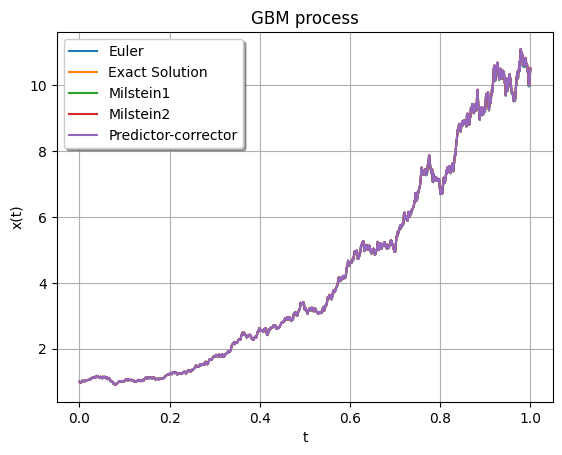

In [8]:
theta1 = 1
theta2 = 1/2
params = [theta1, theta2]

dwt = np.random.normal(0, 1, size = (Nt, Nx)) * np.sqrt(T/Nt)


BSMp = BSMprocess(params, T, Nx, Nt, init_state)
t_data, x_data = BSMp.EulerSolution(dwt)
plt.plot(t_data, x_data, label = 'Euler')

t_data, x_data = BSMp.ExactSolution(dwt)
plt.plot(t_data, x_data, label = 'Exact Solution')

t_data, x_data = BSMp.Milstein1Solution(dwt)
plt.plot(t_data, x_data, label = 'Milstein1')

t_data, x_data = BSMp.Milstein2Solution(dwt)
plt.plot(t_data, x_data, label = 'Milstein2')

t_data, x_data = BSMp.PredictorCorrectorSolution(dwt, 1/2, 1/2)
plt.plot(t_data, x_data, label = 'Predictor-corrector')

plt.title("GBM process")
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

Task. Compare the different approximations and the exact solution Brownian motion
for different levels of discretization
$$
N=\{2, 4, 8, 128, 256, 512, 1024, 8192, 16384, 32768\}
$$
being the number of subintervals of $[0,1]$.
As the result provide the table with maximum absolute difference.


In [9]:
# your code

Task. Conduct a study of the influence of the choice of values $\alpha$ and $\eta$ ​​on the accuracy of the  solution and plot a 3D graph where the x-axis is $α$'s values, y-axis is $\eta$'s values, and z-axis are maximum absolute difference between the exact solution and the predictor-corrector approximation.



In [10]:
# your code

Task 2.  Repeat the Task 1 for the Cox-Ingersoll-Ross process
$$
dX_t = (\theta_1 - \theta_2X_t)dt + \theta_3 \sqrt{ X_t}dW_t, X_0 = 10, (\theta_1, \theta_2, \theta_3) = (6, 3, 2).
$$

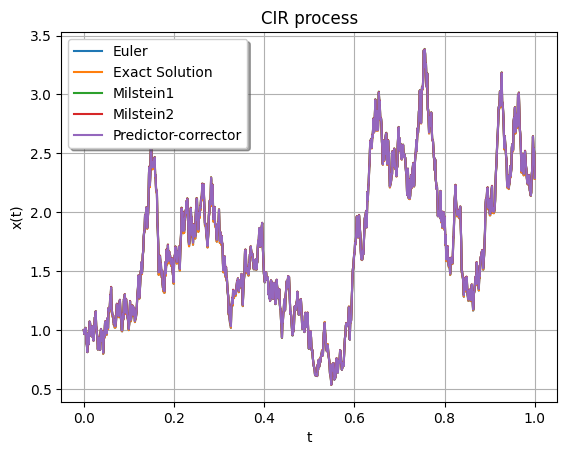

In [11]:
theta1 = 6
theta2 = 3
theta3 = 2
params = [theta1, theta2, theta3]

dwt = np.random.normal(0, 1, size = (Nt, Nx)) * np.sqrt(T/Nt)

CIRp = CIRprocess(params, T, Nx, Nt, init_state)
t_data, x_data = CIRp.EulerSolution(dwt)
plt.plot(t_data, x_data, label = 'Euler')

t_data, x_data = CIRp.ExactSolution(dwt)
plt.plot(t_data, x_data, label = 'Exact Solution')

t_data, x_data = CIRp.Milstein1Solution(dwt)
plt.plot(t_data, x_data, label = 'Milstein1')

t_data, x_data = CIRp.Milstein2Solution(dwt)
plt.plot(t_data, x_data, label = 'Milstein2')

t_data, x_data = CIRp.PredictorCorrectorSolution(dwt, 0.4, 0.6)
plt.plot(t_data, x_data, label = 'Predictor-corrector')

plt.title("CIR process")
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

Task. Compare the speed of convergence for four schemes from Task 1 with extract solution on the graph where the x-axis is  log(N) values, y-axis is  X(t). See example in the study aid.

In [12]:
# your code

Task 3. Generate 100 paths using conditional distribution of
* Ornstein-Uhlenbeck process $θ = (1, 1, 0.5)$,
* Geometric Brownian motion process $θ = (0.3, 0.1)$,
* Cox-Ingersoll-Ross process $θ = (0.4, 0.3, 0.2)$

with $X_0=0.5$.
Plot the random path for each process.

In [13]:
Nx = 1
Nt = 300

T = 1

params_BSM = [1.0, 2.0]
params_CIR = [0.5, 0.2, 1.0]
params_OU  = [1.0, 0.5, 1.5]

init_state = 0.5 * np.ones(Nx)

OUp = OUprocess(params_OU, T, Nx, Nt, init_state)
BSMp = BSMprocess(params_BSM, T, Nx, Nt, init_state)
CIRp = CIRprocess(params_CIR, T, Nx, Nt, init_state)

t_data, x_data_OU = OUp.PathGenerator()
t_data, x_data_BSM = BSMp.PathGenerator()
t_data, x_data_CIR = CIRp.PathGenerator()

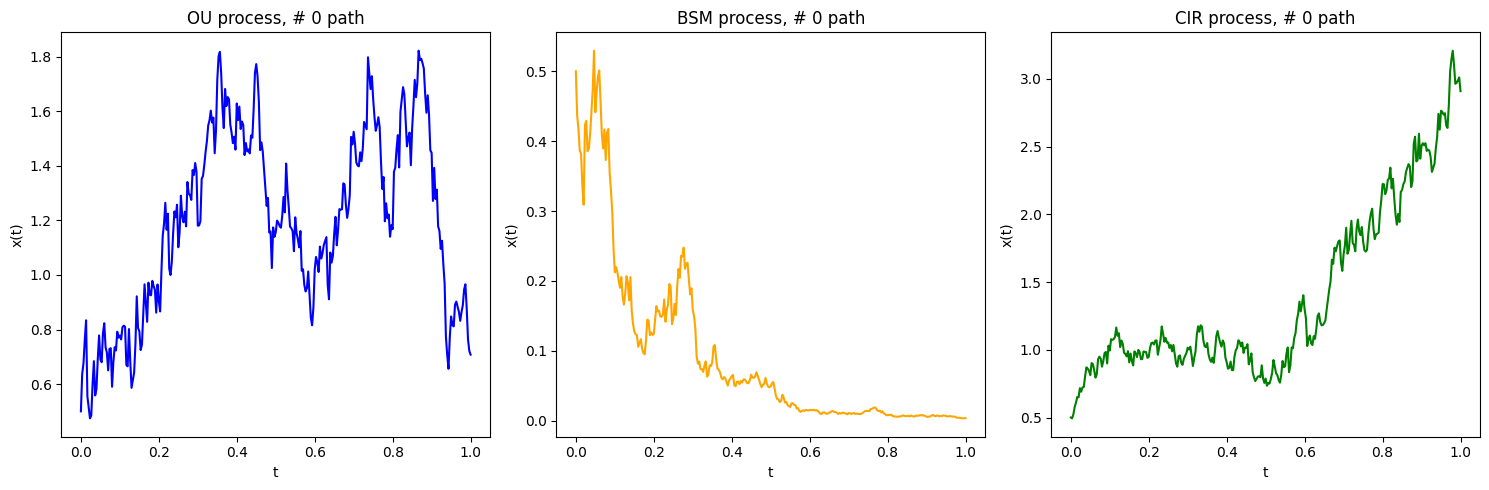

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

n = np.random.randint(0, Nx)

axs[0].plot(t_data, x_data_OU[:,n], color='blue')
axs[0].set_title(f'OU process, # {n} path')
axs[0].set_xlabel('t')
axs[0].set_ylabel('x(t)')

axs[1].plot(t_data, x_data_BSM[:,n], color='orange')
axs[1].set_title(f'BSM process, # {n} path')
axs[1].set_xlabel('t')
axs[1].set_ylabel('x(t)')

axs[2].plot(t_data, x_data_CIR[:,n], color='green')
axs[2].set_title(f'CIR process, # {n} path')
axs[2].set_xlabel('t')
axs[2].set_ylabel('x(t)')

plt.tight_layout()

plt.show()

In [15]:
# save 100 paths to files

pd.DataFrame(data = x_data_OU, index = t_data).to_csv("OUprocess.csv")

pd.DataFrame(data = x_data_BSM, index = t_data).to_csv("BSMprocess.csv")

pd.DataFrame(data = x_data_CIR, index = t_data).to_csv("CIRprocess.csv")

Task. Using the class template from Task 1, create class and design the path generator for one from the following processes:

1.   Modified CIR model;
2.   Chan-Karolyi-Longstaff-Sanders family of models;
1.   Nonlinear mean reversion Ait-Sahalia model;
2.   Jacobi diffusion process;
1.   Ahn and Gao (inverse of Feller’s square root) model;
2.   Radial Ornstein-Uhlenbeck process.

In [16]:
# your code

Task 4. For the processes from previous task plot
* cumulative distribution (cdf),
* density function (pdf),      
* calculate the 90\%-quantile.

In [17]:
def ecdf(data):
    x = np.sort(data)
    y = np.arange(len(x))/float(len(x))
    return x, y

/tmp/ipykernel_2375/3038629395.py:63: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


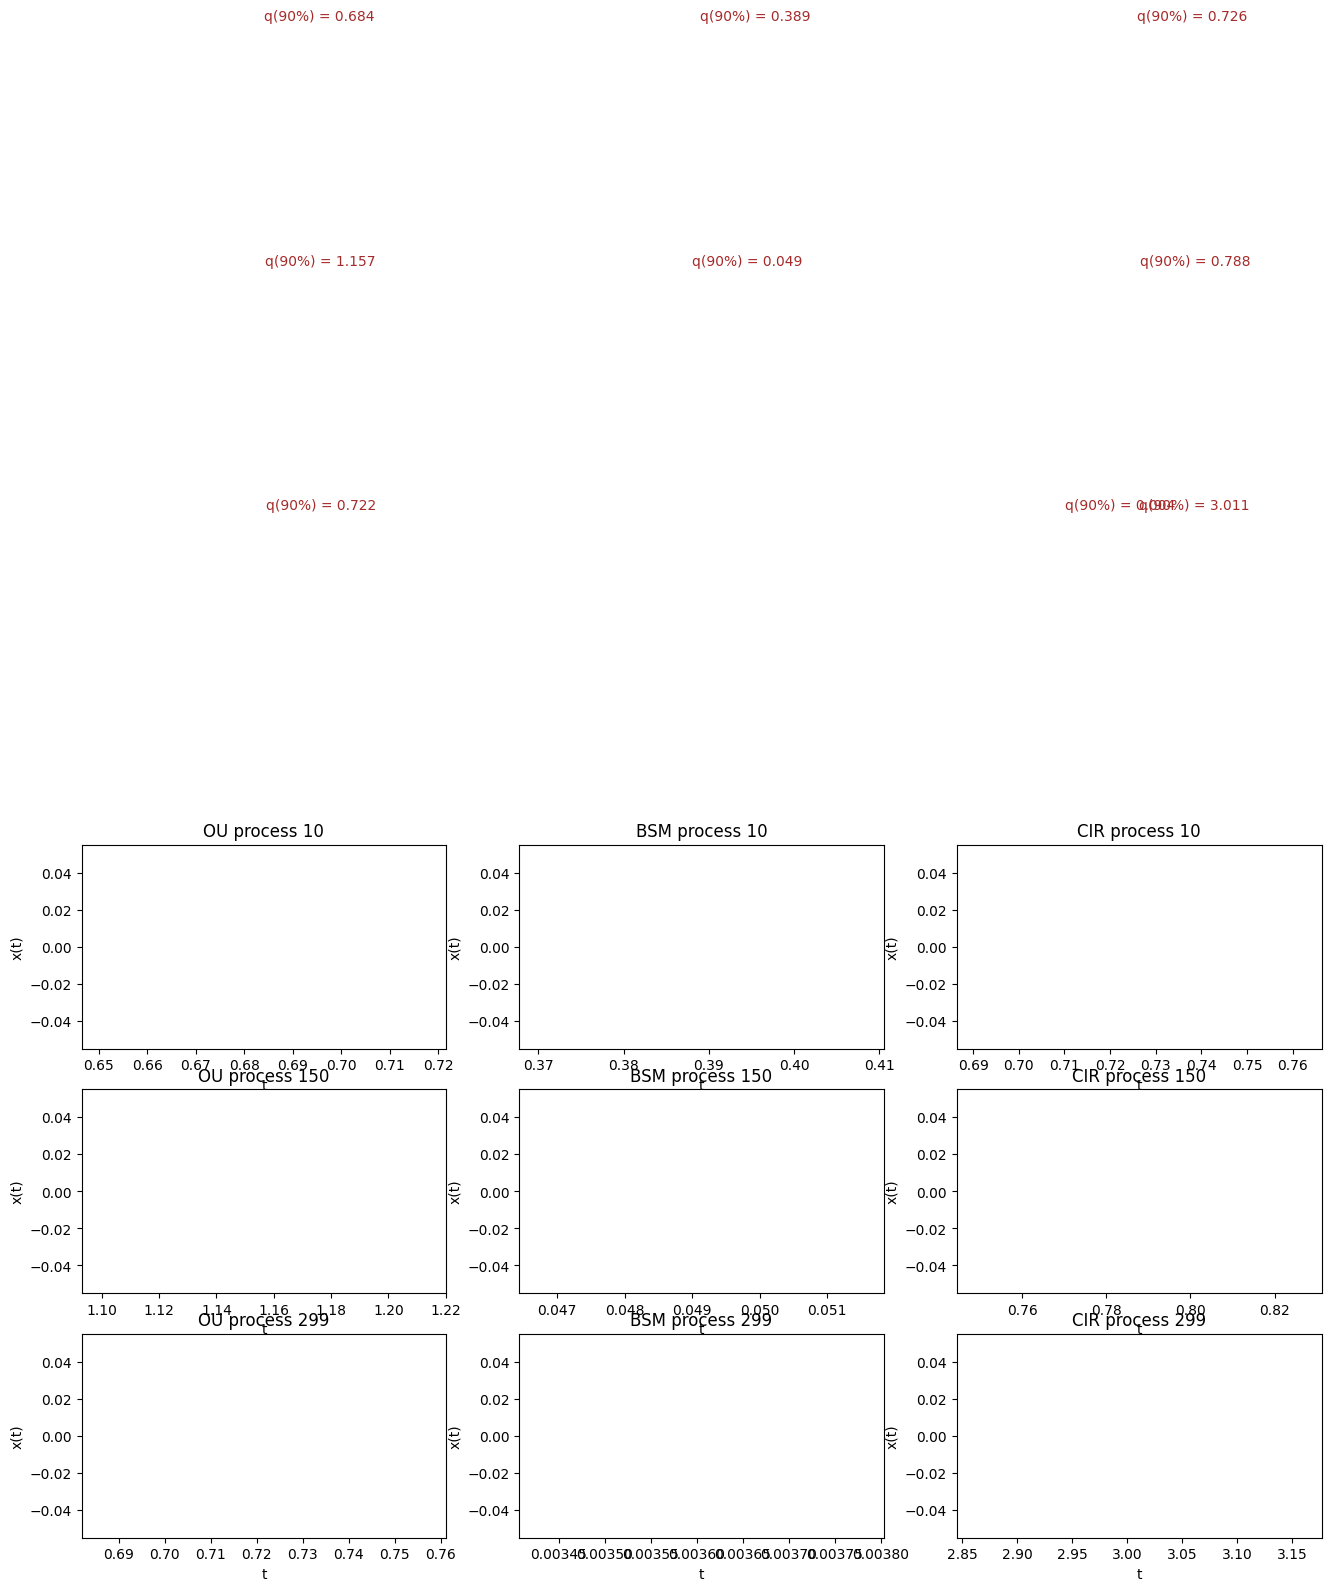

In [18]:
#cdf function and 90% quantile

#distributions become more widely and change with time

fig, axs = plt.subplots(3, 3, figsize=(16, 9))

n = 10

axs[0][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[0][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[0][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[0][1].plot(*ecdf(x_data_BSM[n]), color='green')
axs[0][1].set_title(f'BSM process {n}')
val = round(np.quantile(x_data_BSM[n], 0.9),3)
axs[0][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[0][2].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[0][2].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[0][2].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

n = Nt // 2
axs[1][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[1][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[1][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[1][1].plot(*ecdf(x_data_BSM[n]), color='green')
axs[1][1].set_title(f'BSM process {n}')
val = round(np.quantile(x_data_BSM[n], 0.9),3)
axs[1][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[1][2].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[1][2].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[1][2].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

n = Nt - 1
axs[2][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[2][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[2][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[2][1].plot(*ecdf(x_data_BSM[n]), color='green')
axs[2][1].set_title(f'BSM process {n}')
val = round(np.quantile(x_data_BSM[n], 0.9),3)
axs[2][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[2][2].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[2][2].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[2][2].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

for k in range(0, 3):
    for j in range(0, 3):
        #axs[k][j].set_ylim(0, 1)
        #axs[k][j].set_xlim(0, 2)
        axs[k][j].set_xlabel('t')
        axs[k][j].set_ylabel('x(t)')

plt.tight_layout()
plt.show()

Task. Perform the Kolmogorov-Smirnov test for two samples and present your conclusions. Add vertical lines (90\%-quantile) into plots.
Resize the range on the X-axis so that all curves for one process have the same range.    

In [19]:
# your code

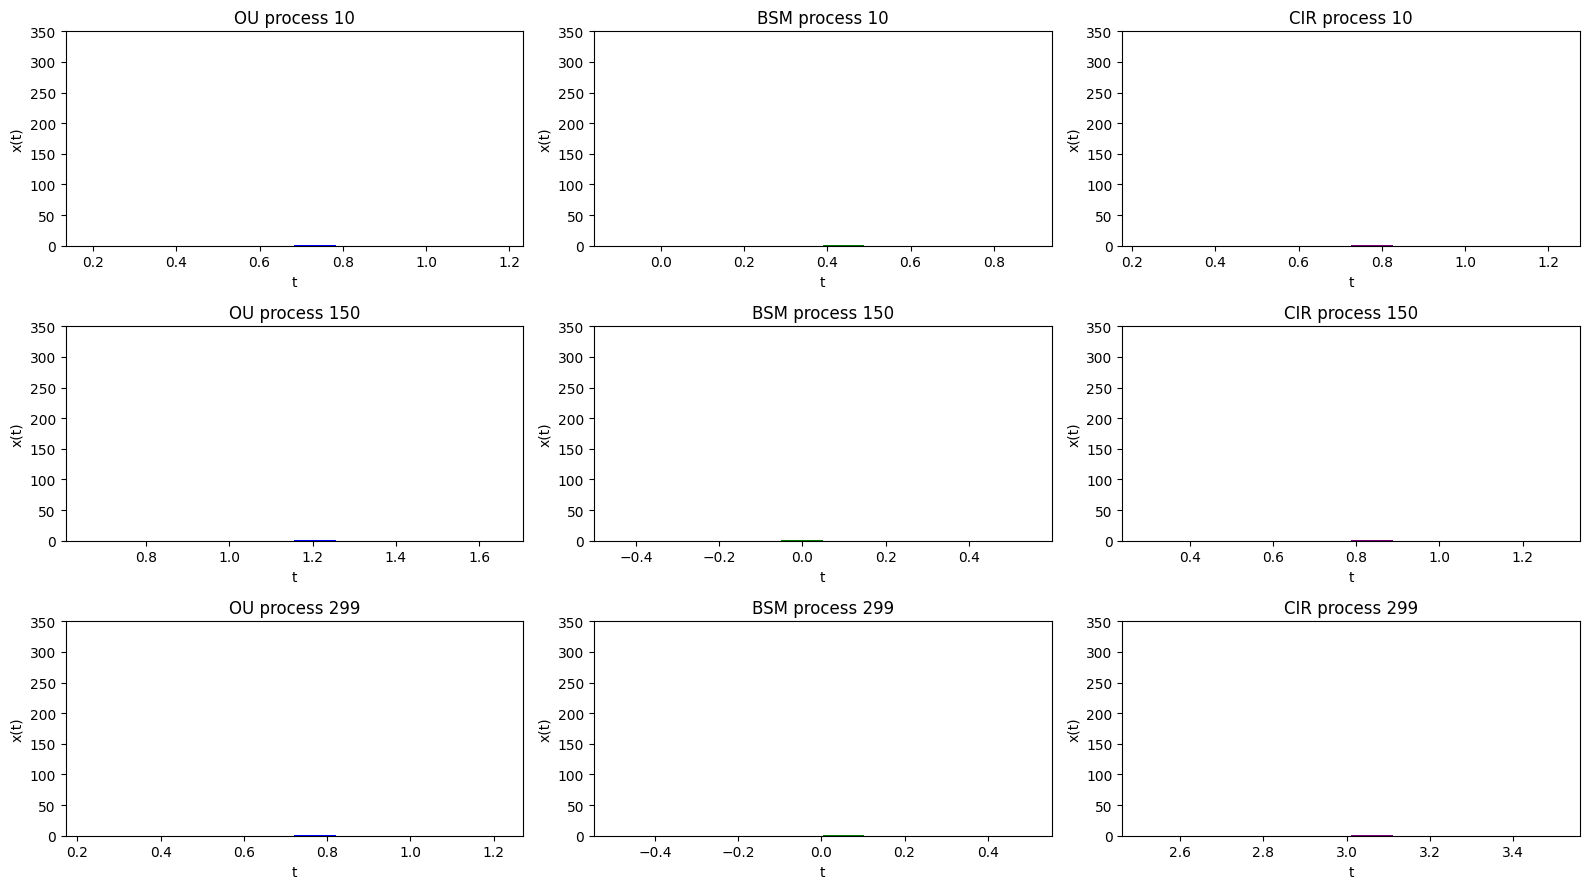

In [20]:
#density function

fig, axs = plt.subplots(3, 3, figsize=(16, 9))

n = 10

axs[0][0].hist(x_data_OU[n], color='blue')
axs[0][0].set_title(f'OU process {n}')

axs[0][1].hist(x_data_BSM[n], color='green')
axs[0][1].set_title(f'BSM process {n}')

axs[0][2].hist(x_data_CIR[n], color='purple')
axs[0][2].set_title(f'CIR process {n}')

n = Nt // 2
axs[1][0].hist(x_data_OU[n], color='blue')
axs[1][0].set_title(f'OU process {n}')

axs[1][1].hist(x_data_BSM[n], color='green')
axs[1][1].set_title(f'BSM process {n}')

axs[1][2].hist(x_data_CIR[n], color='purple')
axs[1][2].set_title(f'CIR process {n}')

n = Nt - 1
axs[2][0].hist(x_data_OU[n], color='blue')
axs[2][0].set_title(f'OU process {n}')

axs[2][1].hist(x_data_BSM[n], color='green')
axs[2][1].set_title(f'BSM process {n}')

axs[2][2].hist(x_data_CIR[n], color='purple')
axs[2][2].set_title(f'CIR process {n}')

for k in range(0, 3):
    for j in range(0, 3):
        axs[k][j].set_ylim(0, 350)
        #axs[k][j].set_xlim(0, 2)
        axs[k][j].set_xlabel('t')
        axs[k][j].set_ylabel('x(t)')

plt.tight_layout()

plt.show()

Task. Perform a normality test on the histograms and present your conclusions.

Task 5.

In [21]:
#to get stationary state we set initial state to be stationary
#generate 1000 trajectories using conditional distribution
#BSM doesnt have stationary state

#Distribution properties do not change as expected for stationary state

Nx = 1000
Nt = 300

T = 1

params_OU = [1, 1, 0.5]
paramsCIR = [0.4, 0.3, 0.2]


OUp = OUprocess(params_OU, T, Nx, Nt)
OUp.init_state = OUp.StationaryState()

CIRp = CIRprocess(params_OU, T, Nx, Nt)
CIRp.init_state = CIRp.StationaryState()

t_data, x_data_OU = OUp.PathGenerator()

t_data, x_data_CIR = CIRp.PathGenerator()

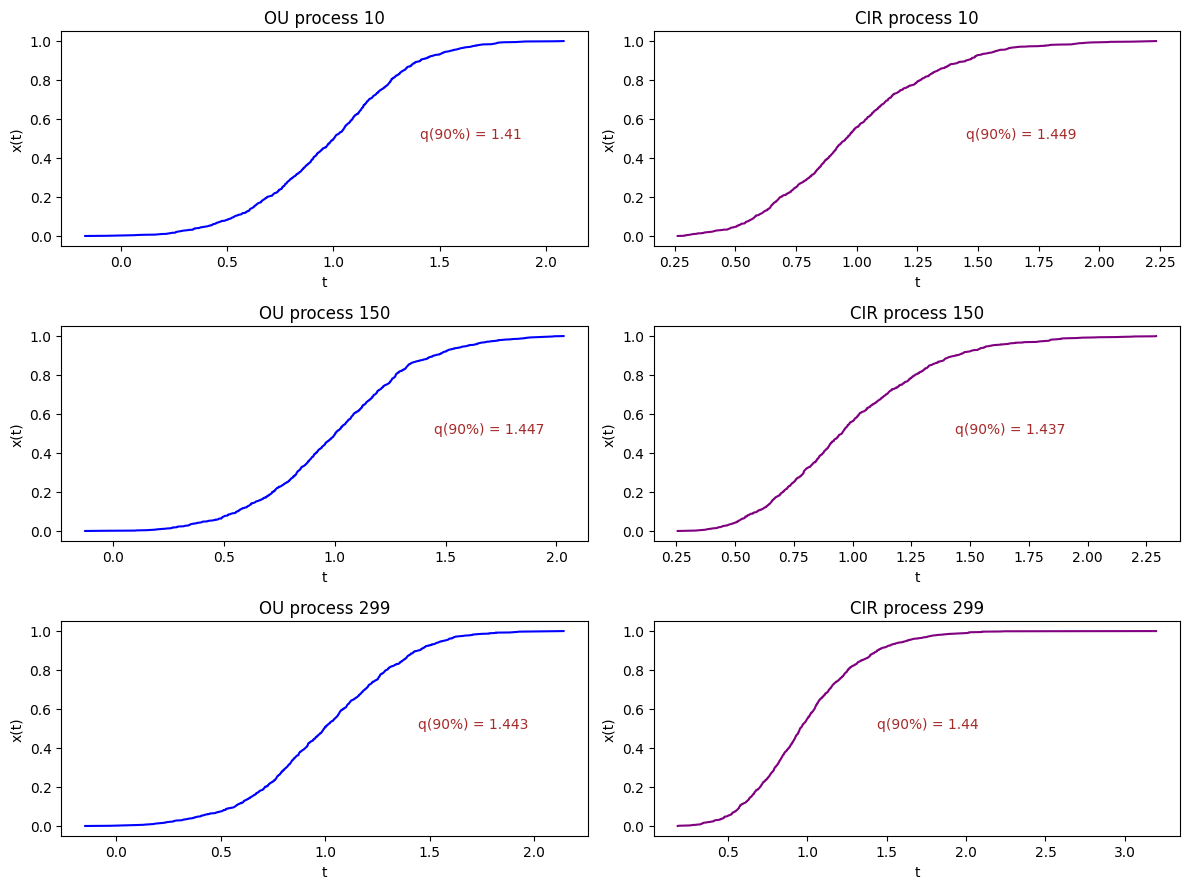

In [22]:
#cdf function and 90% quantile

fig, axs = plt.subplots(3, 2, figsize=(12, 9))

n = 10

axs[0][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[0][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[0][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[0][1].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[0][1].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[0][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

n = Nt // 2
axs[1][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[1][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[1][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[1][1].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[1][1].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[1][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

n = Nt - 1
axs[2][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[2][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[2][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[2][1].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[2][1].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[2][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

for k in range(0, 3):
    for j in range(0, 2):
        #axs[k][j].set_ylim(0, 1)
        #axs[k][j].set_xlim(0, 2)
        axs[k][j].set_xlabel('t')
        axs[k][j].set_ylabel('x(t)')

plt.tight_layout()

plt.show()

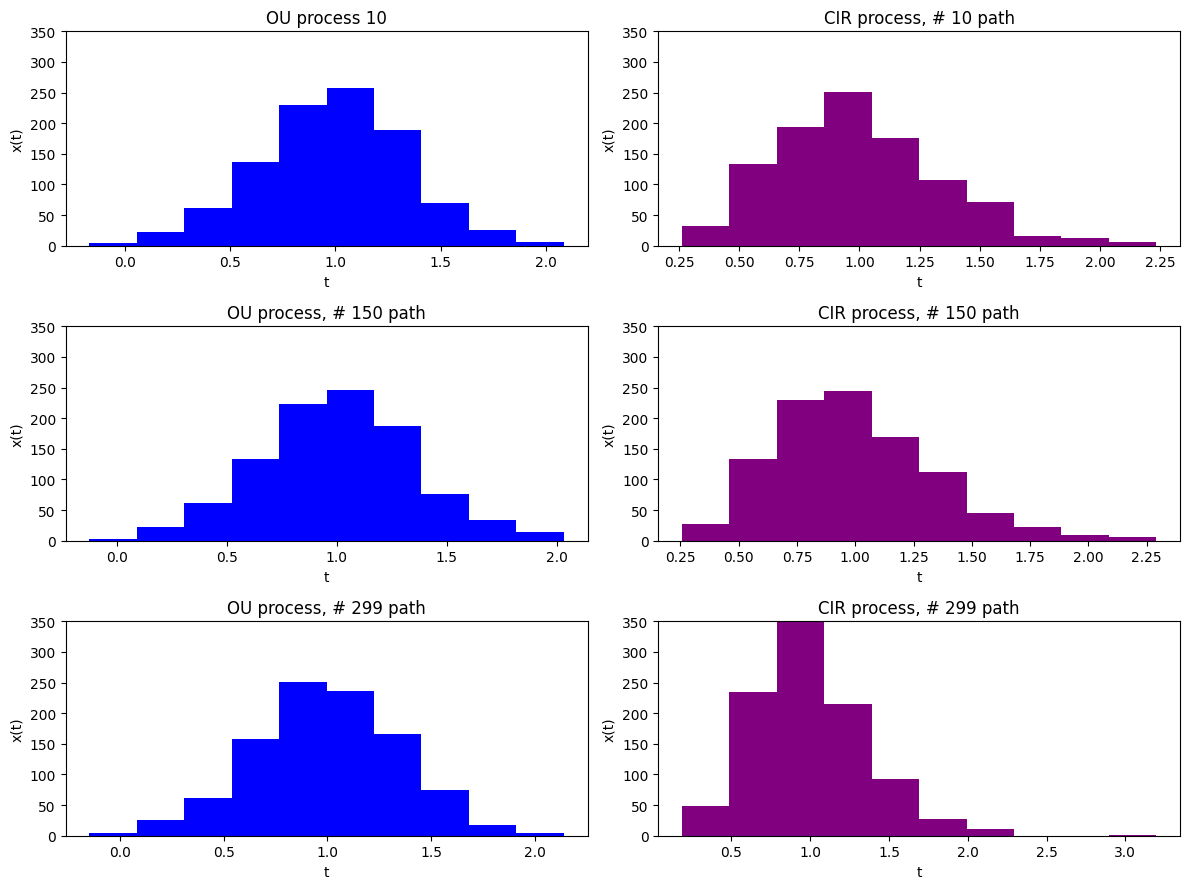

In [23]:
#density function

fig, axs = plt.subplots(3, 2, figsize=(12, 9))

n = 10

axs[0][0].hist(x_data_OU[n], color='blue')
axs[0][0].set_title(f'OU process {n}')

axs[0][1].hist(x_data_CIR[n], color='purple')
axs[0][1].set_title(f'CIR process, # {n} path')

n = Nt // 2
axs[1][0].hist(x_data_OU[n], color='blue')
axs[1][0].set_title(f'OU process, # {n} path')

axs[1][1].hist(x_data_CIR[n], color='purple')
axs[1][1].set_title(f'CIR process, # {n} path')

n = Nt - 1
axs[2][0].hist(x_data_OU[n], color='blue')
axs[2][0].set_title(f'OU process, # {n} path')

axs[2][1].hist(x_data_CIR[n], color='purple')
axs[2][1].set_title(f'CIR process, # {n} path')

for k in range(0, 3):
    for j in range(0, 2):
        axs[k][j].set_ylim(0, 350)
        #axs[k][j].set_xlim(0, 2)
        axs[k][j].set_xlabel('t')
        axs[k][j].set_ylabel('x(t)')

plt.tight_layout()

plt.show()

# Задачи

Задача 1. Сравнительный анализ численных схем

1. Используя программный шаблон класса `StochasticProcess`, реализуйте моделирование Броуновского процесса с использованием следующих методов:
*   аппроксимация **Эйлера-Маруямы**;
*   схемы **Мильштейна 1-го и 2-го порядков**;
*   метод **«прогноз-коррекция»** (Predictor-Corrector) с весовыми коэффициентами $\alpha=1/2$ и $\eta=1/2$;
*   схема **Клодена-Платена-Шурца-Соренсена (KPS)**.

2. Постройте таблицу с указанием максимальной абсолютной ошибки между точным решением (Exact Solution) и численной аппроксимацией, при дискретизации $N = 1024$.

3. Сделайте выводы.



,scheme,max_abs_error
4,KPS,0.000099
2,Milstein 2,0.000616
3,Predictor-Corrector,0.002033
1,Milstein 1,0.025617
0,Euler-Maruyama,0.036394


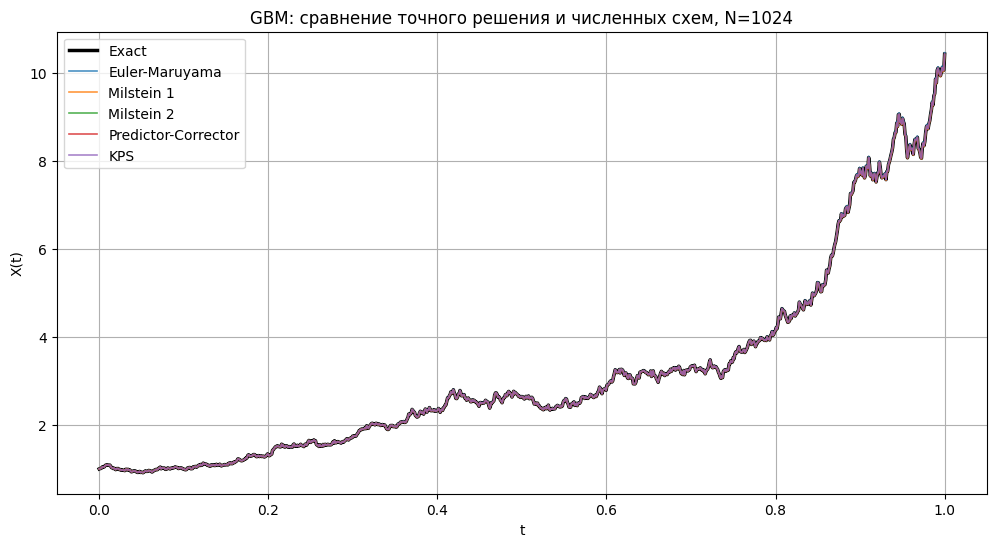

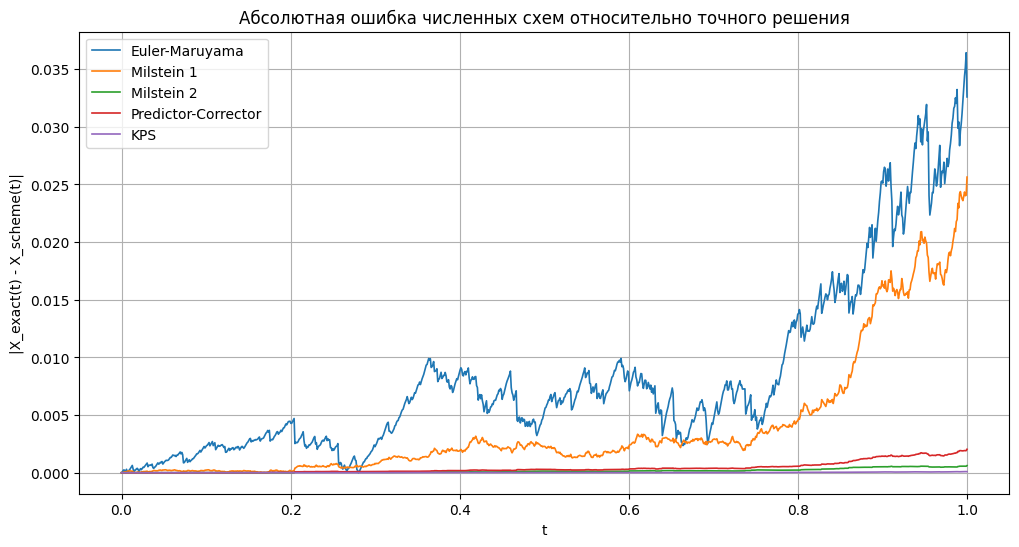

Вывод: при N = 1024 минимальную максимальную абсолютную ошибку в данном эксперименте показала схема KPS с ошибкой 9.876e-05. 


In [32]:


np.random.seed(42)

# Вспомогательные функции

def max_abs_error(x_exact, x_approx):
    return float(np.max(np.abs(np.asarray(x_exact) - np.asarray(x_approx))))


def KPS_solution(process, dwt, seed=123):
    #Схема Клодена–Платена–Шурца–Соренсена для одномерного SDE.

    rng = np.random.default_rng(seed)
    dt = process.T / process.Nt
    t_data = np.linspace(0, process.T, process.Nt + 1)
    x_data = np.zeros((process.Nt + 1, process.Nx))
    x_data[0] = process.DefaultInitState() if process.init_state is None else process.init_state

    # ΔU | ΔW:  E[ΔU|ΔW] = 0.5 dt ΔW, Var(ΔU|ΔW)=dt^3/12
    z = rng.normal(size=dwt.shape)
    dU = 0.5 * dt * dwt + np.sqrt(dt**3 / 12) * z

    for i in range(1, process.Nt + 1):
        x = x_data[i - 1]
        b = process.bxt(x)
        sig = process.sigmaxt(x)
        bx = process.bxt_x(x)
        bxx = process.bxt_xx(x)
        sx = process.sigmaxt_x(x)
        sxx = process.sigmaxt_xx(x)
        dw = dwt[i - 1]
        du = dU[i - 1]

        sig_sx_x = sx**2 + sig * sxx  # derivative of sigma*sigma_x
        x_new = (x + b * dt + sig * dw
                 + 0.5 * sig * sx * (dw**2 - dt)
                 + sig * bx * du
                 + 0.5 * (b * bx + 0.5 * sig**2 * bxx) * dt**2
                 + (b * sx + 0.5 * sig**2 * sxx) * (dw * dt - du)
                 + 0.5 * sig * sig_sx_x * ((dw**2 / 3) - dt) * dw)
        x_data[i] = x_new
    return t_data, x_data


T = 1
Nx = 1
Nt = 1024
x0 = 1.0
init_state = x0 * np.ones(Nx)
theta1, theta2 = 2.0, 0.5
params = [theta1, theta2]

dt = T / Nt
dwt = np.random.normal(0, np.sqrt(dt), size=(Nt, Nx))
process = BSMprocess(params, T, Nx, Nt, init_state)

solutions = {}
t_data, solutions['Exact'] = process.ExactSolution(dwt)
_, solutions['Euler-Maruyama'] = process.EulerSolution(dwt)
_, solutions['Milstein 1'] = process.Milstein1Solution(dwt)
_, solutions['Milstein 2'] = process.Milstein2Solution(dwt)
_, solutions['Predictor-Corrector'] = process.PredictorCorrectorSolution(dwt, eta=0.5, alpha=0.5)
_, solutions['KPS'] = KPS_solution(process, dwt)

# Таблица ошибок
errors_task1 = pd.DataFrame({
    'scheme': [name for name in solutions if name != 'Exact'],
    'max_abs_error': [max_abs_error(solutions['Exact'], solutions[name]) for name in solutions if name != 'Exact']
}).sort_values('max_abs_error')

display(errors_task1)

# График траекторий
plt.figure(figsize=(12, 6))

plt.plot(t_data, solutions['Exact'][:, 0], label='Exact', linewidth=2.5, color='black')

for name, x in solutions.items():
    if name != 'Exact':
        plt.plot(t_data, x[:, 0], label=name, linewidth=1.2, alpha=0.8)

plt.title('GBM: сравнение точного решения и численных схем, N=1024')
plt.xlabel('t')
plt.ylabel('X(t)')
plt.grid(True)
plt.legend()
plt.show()


# График абсолютных ошибок по времени
plt.figure(figsize=(12, 6))

for name, x in solutions.items():
    if name != 'Exact':
        error = np.abs(solutions['Exact'][:, 0] - x[:, 0])
        plt.plot(t_data, error, label=name, linewidth=1.2)

plt.title('Абсолютная ошибка численных схем относительно точного решения')
plt.xlabel('t')
plt.ylabel('|X_exact(t) - X_scheme(t)|')
plt.grid(True)
plt.legend()
plt.show()

best = errors_task1.iloc[0]

print(
    f"Вывод: при N = {Nt} минимальную максимальную абсолютную ошибку "
    f"в данном эксперименте показала схема {best['scheme']} "
    f"с ошибкой {best['max_abs_error']:.3e}. "
)

Задача 2. Исследование скорости сходимости

1. Проведите количественный анализ точности аппроксимаций.
Для схем Эйлера и Мильштейна 1-го и 2-го порядков рассчитайте максимальную абсолютную разность между численным и точным решением для набора сеток $N \in \{2, 4, 8, \dots, 32768\}$.

2. Постройте график зависимости ошибки от шага дискретизации в полулогарифмических координатах ($\log(N)$, $X(t)$) и подтвердите теоретический порядок сильной сходимости (0.5 для Эйлера, 1.0 для Мильштейна 1-го порядка, 2.0 для Мильштейна 2-го порядка).

3. Сделайте выводы.



,N,dt,Euler,Milstein 1,Milstein 2
0,2,0.500000,7.124435,6.961252,2.879375
1,4,0.250000,5.130906,4.977948,1.103168
2,8,0.125000,3.040922,3.208483,0.247717
3,128,0.007812,0.762019,0.251040,0.005141
4,256,0.003906,0.532084,0.134097,0.007776
5,512,0.001953,0.408484,0.071509,0.005711
6,1024,0.000977,0.208342,0.034475,0.000598
7,8192,0.000122,0.036100,0.004421,0.000051
8,16384,0.000061,0.035278,0.002299,0.000104
9,32768,0.000031,0.005231,0.001120,0.000017


,scheme,empirical_order
0,Euler,0.666415
1,Milstein 1,0.918035
2,Milstein 2,1.192914


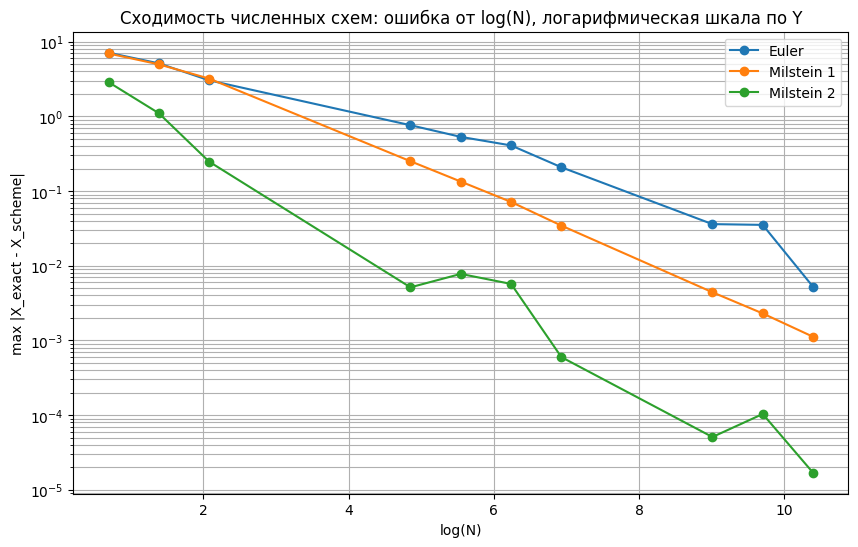

Вывод: при уменьшении шага дискретизации ошибка убывает. Эйлер обычно сходится медленнее, Мильштейн 1 — быстрее. 


In [33]:


np.random.seed(123)

T = 1
Nx = 1
x0 = 1.0
params = [2.0, 0.5]
N_values = np.array([2, 4, 8, 128, 256, 512, 1024, 8192, 16384, 32768])
N_max = int(N_values.max())

# Генерируем один тонкий винеровский путь и агрегируем при переходе к более грубым сеткам.
dt_fine = T / N_max
dwt_fine = np.random.normal(0, np.sqrt(dt_fine), size=(N_max, Nx))

rows = []
for N in N_values:
    block = N_max // N
    dwt = dwt_fine.reshape(N, block, Nx).sum(axis=1)
    process = BSMprocess(params, T, Nx, int(N), x0 * np.ones(Nx))
    _, x_exact = process.ExactSolution(dwt)
    _, x_euler = process.EulerSolution(dwt)
    _, x_m1 = process.Milstein1Solution(dwt)
    _, x_m2 = process.Milstein2Solution(dwt)
    rows.append({
        'N': int(N),
        'dt': T / N,
        'Euler': max_abs_error(x_exact, x_euler),
        'Milstein 1': max_abs_error(x_exact, x_m1),
        'Milstein 2': max_abs_error(x_exact, x_m2),
    })

conv_table = pd.DataFrame(rows)
display(conv_table)

# Оценка наклона log(error) ~ p log(dt): p — эмпирический порядок сходимости.
orders = []
for scheme in ['Euler', 'Milstein 1', 'Milstein 2']:
    y = np.log(np.maximum(conv_table[scheme].values, 1e-16))
    x = np.log(conv_table['dt'].values)
    p = np.polyfit(x, y, 1)[0]
    orders.append({'scheme': scheme, 'empirical_order': p})
orders_table = pd.DataFrame(orders)
display(orders_table)

plt.figure(figsize=(10, 6))
for scheme in ['Euler', 'Milstein 1', 'Milstein 2']:
    plt.plot(np.log(conv_table['N']), conv_table[scheme], marker='o', label=scheme)
plt.yscale('log')
plt.title('Сходимость численных схем: ошибка от log(N), логарифмическая шкала по Y')
plt.xlabel('log(N)')
plt.ylabel('max |X_exact - X_scheme|')
plt.grid(True, which='both')
plt.legend()
plt.show()

print('Вывод: при уменьшении шага дискретизации ошибка убывает. Эйлер обычно сходится медленнее, '
      'Мильштейн 1 — быстрее. ')


Задача 3. Оптимизация метода «прогноз-коррекция»

Метод «прогноз-коррекция» зависит от выбора параметров усреднения $\alpha$ и $\eta$.

1. Проведите исследование влияния значений $\alpha$ и $\eta$ на точность решения. Модель стохастического процесса укажите самостоятельно.

2. Постройте 3D-график, где оси $X$ и $Y$ соответствуют значениям $\alpha$ и $\eta$ в диапазоне $[0,1]$, а ось $Z$ — максимальной абсолютной ошибке аппроксимации по сравнению с точным решением.

3. Сделайте выводы.



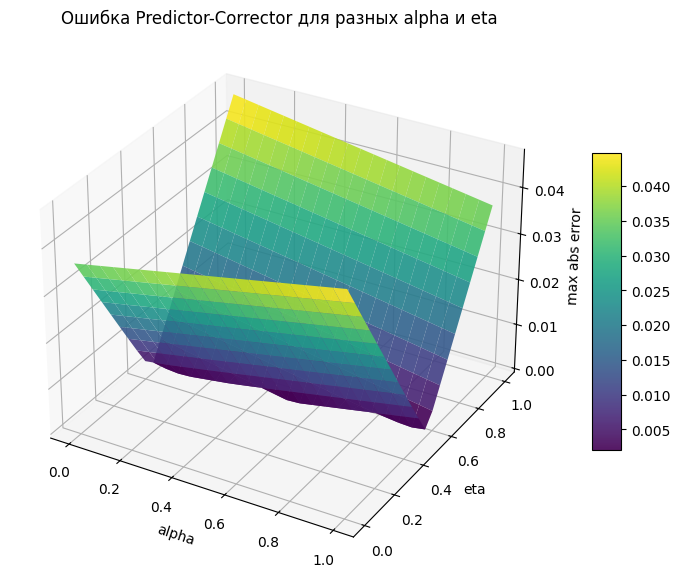

,alpha,eta,max_abs_error
220,0.50,0.50,0.000185
221,0.55,0.50,0.000344
250,0.95,0.55,0.000579
191,0.10,0.45,0.000686
219,0.45,0.50,0.000708
249,0.90,0.55,0.000730
192,0.15,0.45,0.000833
222,0.60,0.50,0.000870
190,0.05,0.45,0.000939
251,1.00,0.55,0.001033


Лучшие параметры на данной траектории: alpha=0.50, eta=0.50, max error=1.854e-04. Значения alpha=eta=0 соответствуют схеме Эйлера; увеличение eta сильнее меняет диффузионную часть корректора и поэтому заметно влияет на ошибку.


In [34]:


np.random.seed(7)

T = 1
Nx = 1
Nt = 1024
x0 = 1.0
params = [2.0, 0.5]
dt = T / Nt
dwt = np.random.normal(0, np.sqrt(dt), size=(Nt, Nx))
process = BSMprocess(params, T, Nx, Nt, x0 * np.ones(Nx))
_, x_exact = process.ExactSolution(dwt)

alpha_grid = np.linspace(0, 1, 21)
eta_grid = np.linspace(0, 1, 21)
A, E = np.meshgrid(alpha_grid, eta_grid)
Zerr = np.zeros_like(A)

for i, eta in enumerate(eta_grid):
    for j, alpha in enumerate(alpha_grid):
        _, x_pc = process.PredictorCorrectorSolution(dwt, eta=float(eta), alpha=float(alpha))
        Zerr[i, j] = max_abs_error(x_exact, x_pc)

best_idx = np.unravel_index(np.argmin(Zerr), Zerr.shape)
best_eta = eta_grid[best_idx[0]]
best_alpha = alpha_grid[best_idx[1]]
best_error = Zerr[best_idx]

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(A, E, Zerr, cmap='viridis', edgecolor='none', alpha=0.9)
ax.set_title('Ошибка Predictor-Corrector для разных alpha и eta')
ax.set_xlabel('alpha')
ax.set_ylabel('eta')
ax.set_zlabel('max abs error')
fig.colorbar(surf, shrink=0.55, aspect=10)
plt.show()

pc_grid_table = pd.DataFrame({
    'alpha': A.ravel(),
    'eta': E.ravel(),
    'max_abs_error': Zerr.ravel()
}).sort_values('max_abs_error').head(10)
display(pc_grid_table)

print(f'Лучшие параметры на данной траектории: alpha={best_alpha:.2f}, eta={best_eta:.2f}, '
      f'max error={best_error:.3e}. Значения alpha=eta=0 соответствуют схеме Эйлера; '
      'увеличение eta сильнее меняет диффузионную часть корректора и поэтому заметно влияет на ошибку.')


Задача 4. Моделирование экзотических процессов (из Раздела 8)

1. Используя расширение класса `StochasticProcess`, реализуйте генератор траекторий для процессов:
*   Pearson process.
*   Jacobi process.
*   Radial OU process.
*   Ahn and Gao model.

2. Постройте панели графиков (по одной для каждого процесса):
     - Верхний график: эмпирическая функция распределения (ecdf),  
     - Нижний график: гистограмма плотности (pdf)  
 для различных моментов времени $t=0.1$, $t=0.5$, $t=1.0$.

3. Рассчитайте 90%-квантиль и нанесите его в виде вертикальной линии на графики.

4. Сделайте выводы.

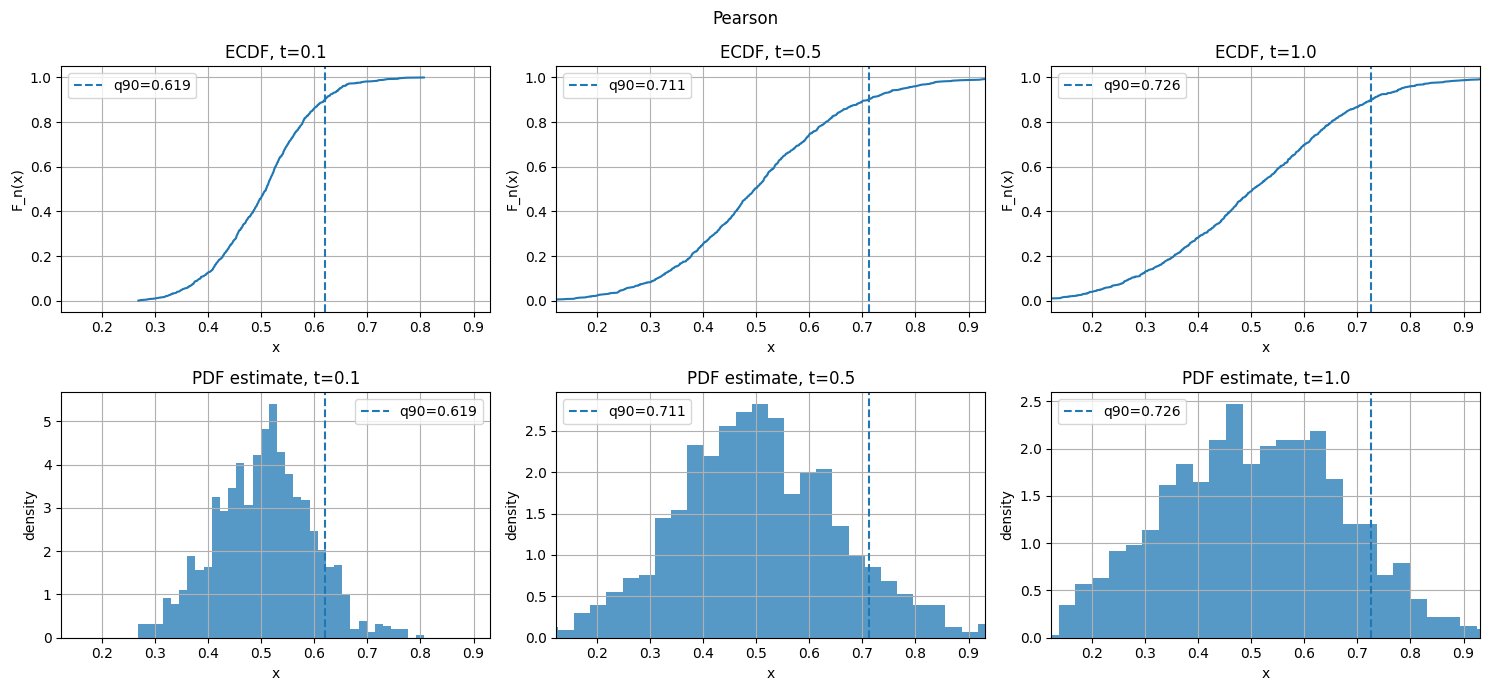

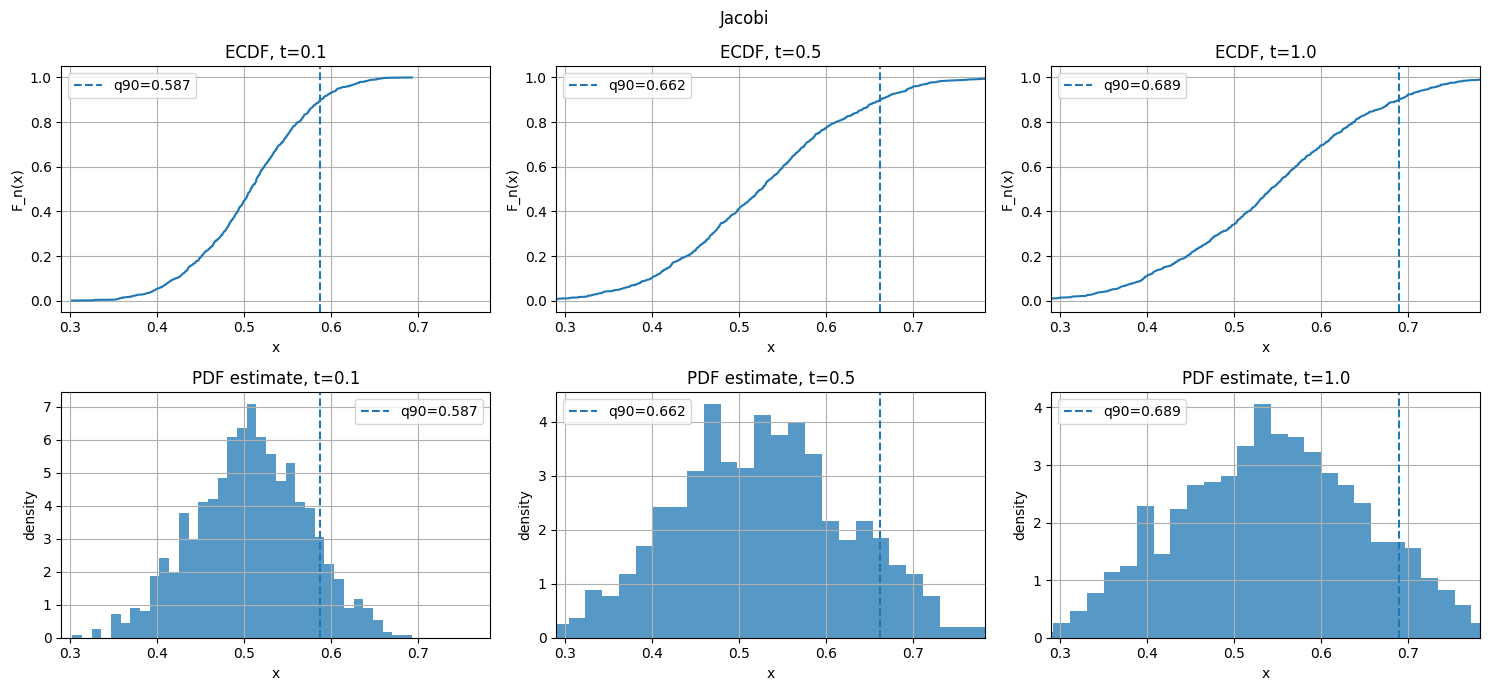

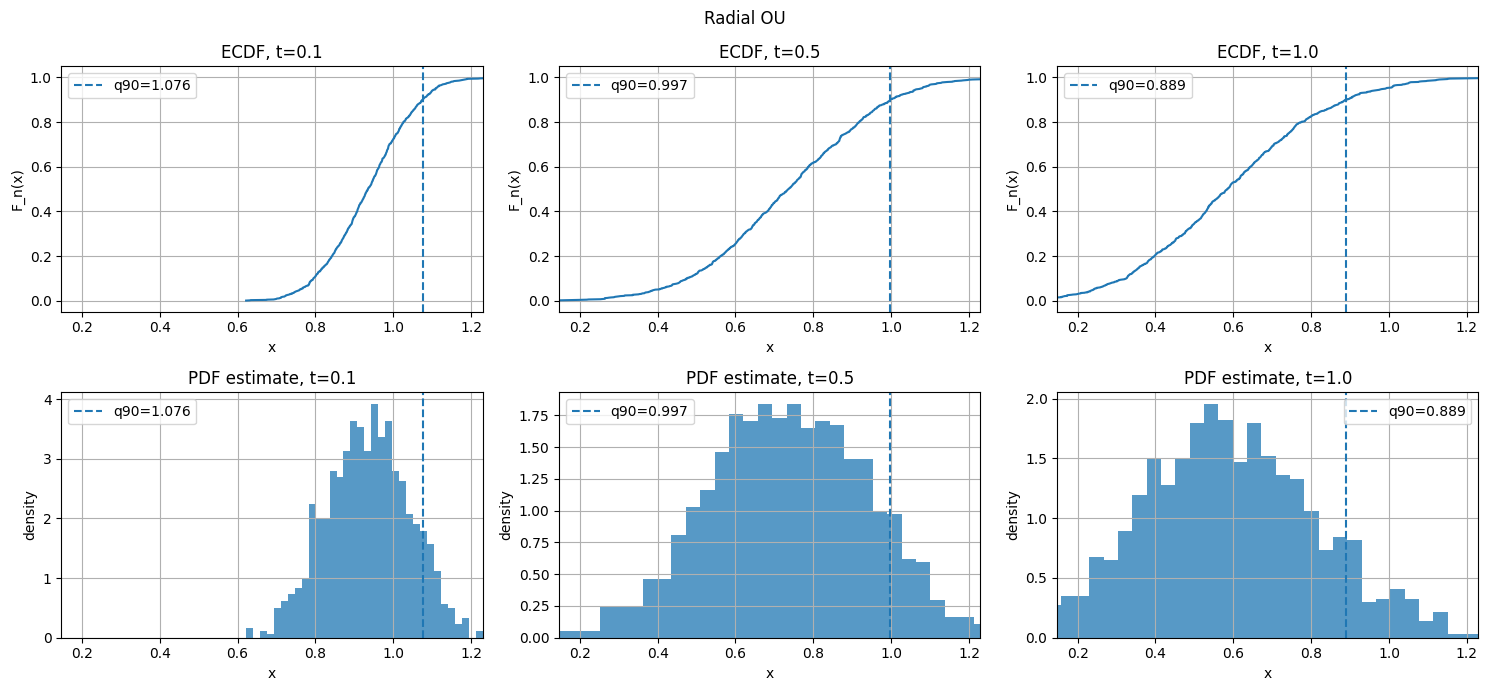

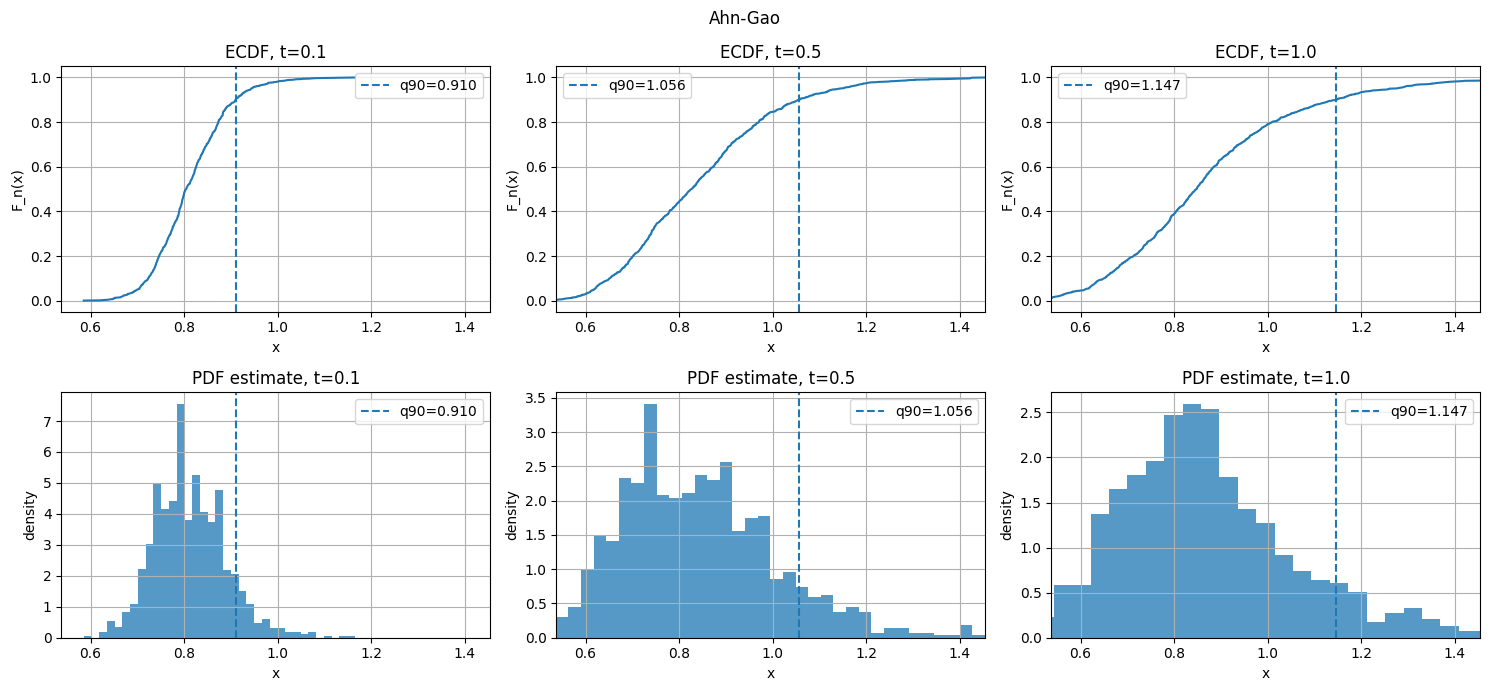

,process,t,q90
0,Pearson,0.1,0.619347
1,Pearson,0.5,0.711497
2,Pearson,1.0,0.726205
3,Jacobi,0.1,0.587490
4,Jacobi,0.5,0.662169
5,Jacobi,1.0,0.688887
6,Radial OU,0.1,1.075820
7,Radial OU,0.5,0.997372
8,Radial OU,1.0,0.889326
9,Ahn-Gao,0.1,0.910128


Вывод: Jacobi-процесс остается в [0,1] из-за вида диффузии sqrt(x(1-x)); Radial OU и Ahn-Gao положительны после проекции. По ECDF видно смещение распределений к их областям притяжения, а 90%-квантили дают удобное численное сравнение хвостов.


In [27]:

np.random.seed(2026)

class PearsonProcess(StochasticProcess):
    """Pearson diffusion: dX = k(mu-X)dt + sqrt(a X^2 + b X + c)dW."""
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        self.k, self.mu, self.a, self.b, self.c = params
        self.bxt = lambda x: self.k * (self.mu - x)
        self.sigmaxt = lambda x: np.sqrt(np.maximum(self.a*x**2 + self.b*x + self.c, 1e-10))
    def DefaultInitState(self):
        return self.mu * np.ones(self.Nx)

class JacobiProcess(StochasticProcess):
    """Jacobi diffusion on [0,1]: dX = k(theta-X)dt + sigma sqrt(X(1-X))dW."""
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        self.k, self.theta, self.sigma = params
        self.bxt = lambda x: self.k * (self.theta - x)
        self.sigmaxt = lambda x: self.sigma * np.sqrt(np.maximum(x*(1-x), 0))
    def DefaultInitState(self):
        return self.theta * np.ones(self.Nx)

class RadialOUProcess(StochasticProcess):
    """Radial OU/Bessel-like process kept positive by reflection."""
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        self.k, self.sigma, self.dim = params
        self.bxt = lambda x: ((self.dim - 1) * self.sigma**2 / (2*np.maximum(x, 1e-6)) - self.k*x)
        self.sigmaxt = lambda x: self.sigma * np.ones_like(x)
    def DefaultInitState(self):
        return np.ones(self.Nx)

class AhnGaoProcess(StochasticProcess):
    """Inverse-Feller/Ahn-Gao style model: dr = r(k + sigma^2 - k theta r)dt - sigma r^(3/2)dW."""
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        self.k, self.theta, self.sigma = params
        self.bxt = lambda x: x * (self.k + self.sigma**2 - self.k*self.theta*x)
        self.sigmaxt = lambda x: -self.sigma * np.maximum(x, 1e-8)**1.5
    def DefaultInitState(self):
        return np.ones(self.Nx) / self.theta


def simulate_projected(process, lower=-np.inf, upper=np.inf):
    dt = process.T / process.Nt
    t_data = np.linspace(0, process.T, process.Nt + 1)
    x_data = np.zeros((process.Nt + 1, process.Nx))
    x_data[0] = process.DefaultInitState() if process.init_state is None else process.init_state
    for i in range(1, process.Nt + 1):
        dw = np.random.normal(0, np.sqrt(dt), size=process.Nx)
        x_new = x_data[i-1] + process.bxt(x_data[i-1]) * dt + process.sigmaxt(x_data[i-1]) * dw
        x_data[i] = np.clip(x_new, lower, upper)
    return t_data, x_data


def ecdf(sample):
    x = np.sort(sample)
    y = np.arange(1, len(x)+1) / len(x)
    return x, y

T = 1
Nt = 300
Nx = 1000
time_points = [0.1, 0.5, 1.0]
idx_points = [int(round(t * Nt / T)) for t in time_points]

processes = {
    'Pearson': (PearsonProcess([1.5, 0.5, 0.05, 0.0, 0.08], T, Nx, Nt, 0.5*np.ones(Nx)), -np.inf, np.inf),
    'Jacobi': (JacobiProcess([2.0, 0.55, 0.45], T, Nx, Nt, 0.5*np.ones(Nx)), 0.0, 1.0),
    'Radial OU': (RadialOUProcess([0.8, 0.35, 3.0], T, Nx, Nt, 1.0*np.ones(Nx)), 1e-6, np.inf),
    'Ahn-Gao': (AhnGaoProcess([0.8, 1.2, 0.35], T, Nx, Nt, 0.8*np.ones(Nx)), 1e-6, np.inf),
}

q90_rows = []
for name, (proc, lower, upper) in processes.items():
    t_data, x_data = simulate_projected(proc, lower, upper)
    fig, axs = plt.subplots(2, 3, figsize=(15, 7))
    fig.suptitle(name)

    # единый диапазон X для всех моментов времени этого процесса
    vals = np.concatenate([x_data[idx] for idx in idx_points])
    xlim = (np.quantile(vals, 0.005), np.quantile(vals, 0.995))

    for col, (t, idx) in enumerate(zip(time_points, idx_points)):
        sample = x_data[idx]
        q90 = float(np.quantile(sample, 0.9))
        q90_rows.append({'process': name, 't': t, 'q90': q90})

        xs, ys = ecdf(sample)
        axs[0, col].plot(xs, ys)
        axs[0, col].axvline(q90, linestyle='--', label=f'q90={q90:.3f}')
        axs[0, col].set_xlim(xlim)
        axs[0, col].set_title(f'ECDF, t={t}')
        axs[0, col].set_xlabel('x')
        axs[0, col].set_ylabel('F_n(x)')
        axs[0, col].grid(True)
        axs[0, col].legend()

        axs[1, col].hist(sample, bins=35, density=True, alpha=0.75)
        axs[1, col].axvline(q90, linestyle='--', label=f'q90={q90:.3f}')
        axs[1, col].set_xlim(xlim)
        axs[1, col].set_title(f'PDF estimate, t={t}')
        axs[1, col].set_xlabel('x')
        axs[1, col].set_ylabel('density')
        axs[1, col].grid(True)
        axs[1, col].legend()

    plt.tight_layout()
    plt.show()

display(pd.DataFrame(q90_rows))
print('Вывод: Jacobi-процесс остается в [0,1] из-за вида диффузии sqrt(x(1-x)); Radial OU и Ahn-Gao положительны '
      'после проекции. По ECDF видно смещение распределений к их областям притяжения.')



Задача 5.
1. Сгенерируйте по 100 траекторий для процессов со следующими параметрами:  
   - OU: $θ = (1.0, 1.0, 0.5)$,  
   - CIR: $θ = (0.4, 0.3, 0.2)$,
   
   $X_0 = 0.5$, $T = 1$, $Nt = 300$, $Nx = 100$.

2. Для каждого процесса вычислите теоретическое стационарное распределение: OU (нормальное распределение), CIR (гамма-распределение) и постройте гистограммы значений процесса в момент $t = T$ (конечное состояние) для всех траекторий и наложите на них график теоретической плотности.

3. Для процессов вычислите условное среднее и дисперсию по теоретическим формулам: OU (условное распределение — нормальное), CIR условное распределение — нецентральное хи-квадрат.   

4. Постройте графики условного среднего $E[X_t | X_0]$ и условной дисперсии $Var[X_t | X_0]$ на интервале $[0, T]$.

5. Вычислите выборочное среднее и дисперсию по всем траекториям в моменты времени: $t = 0.1$, $t = 0.5$, $t = 1.0$. Сравните с теоретическими значениями и прокомментируйте точность моделирования.

6. Постройте панели графиков (по одной для каждого процесса):
     - Верхний график: 10 случайных траекторий.  
     - Средний график: гистограмма конечных состояний с наложенной теоретической плотностью.  
     - Нижний график: условное среднее и дисперсия как функции времени.  

7. Сделайте выводы.

,process,t,sample_mean,theoretical_mean,abs_mean_error,sample_var,theoretical_var,abs_var_error
0,OU,0.1,0.552640,0.547581,0.005059,0.022223,0.022659,0.000436
1,CIR,0.1,0.529060,0.524629,0.004431,0.002258,0.001990,0.000268
2,OU,0.5,0.687723,0.696735,0.009011,0.078274,0.079015,0.000741
3,CIR,0.5,0.623823,0.616077,0.007747,0.010334,0.009717,0.000617
4,OU,1.0,0.845492,0.816060,0.029431,0.119038,0.108083,0.010955
5,CIR,1.0,0.729903,0.715985,0.013918,0.018207,0.018772,0.000564


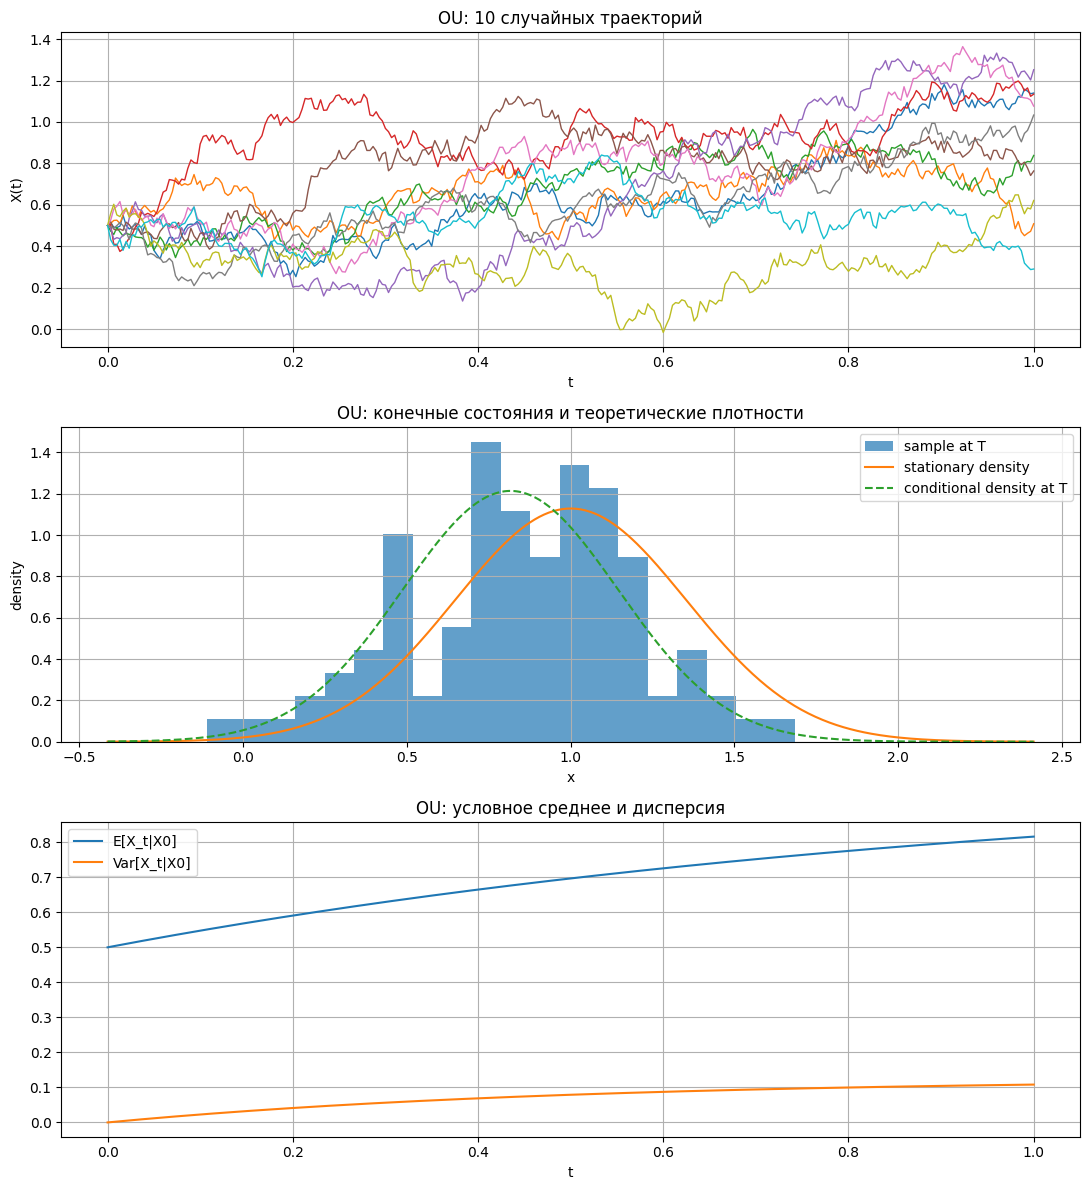

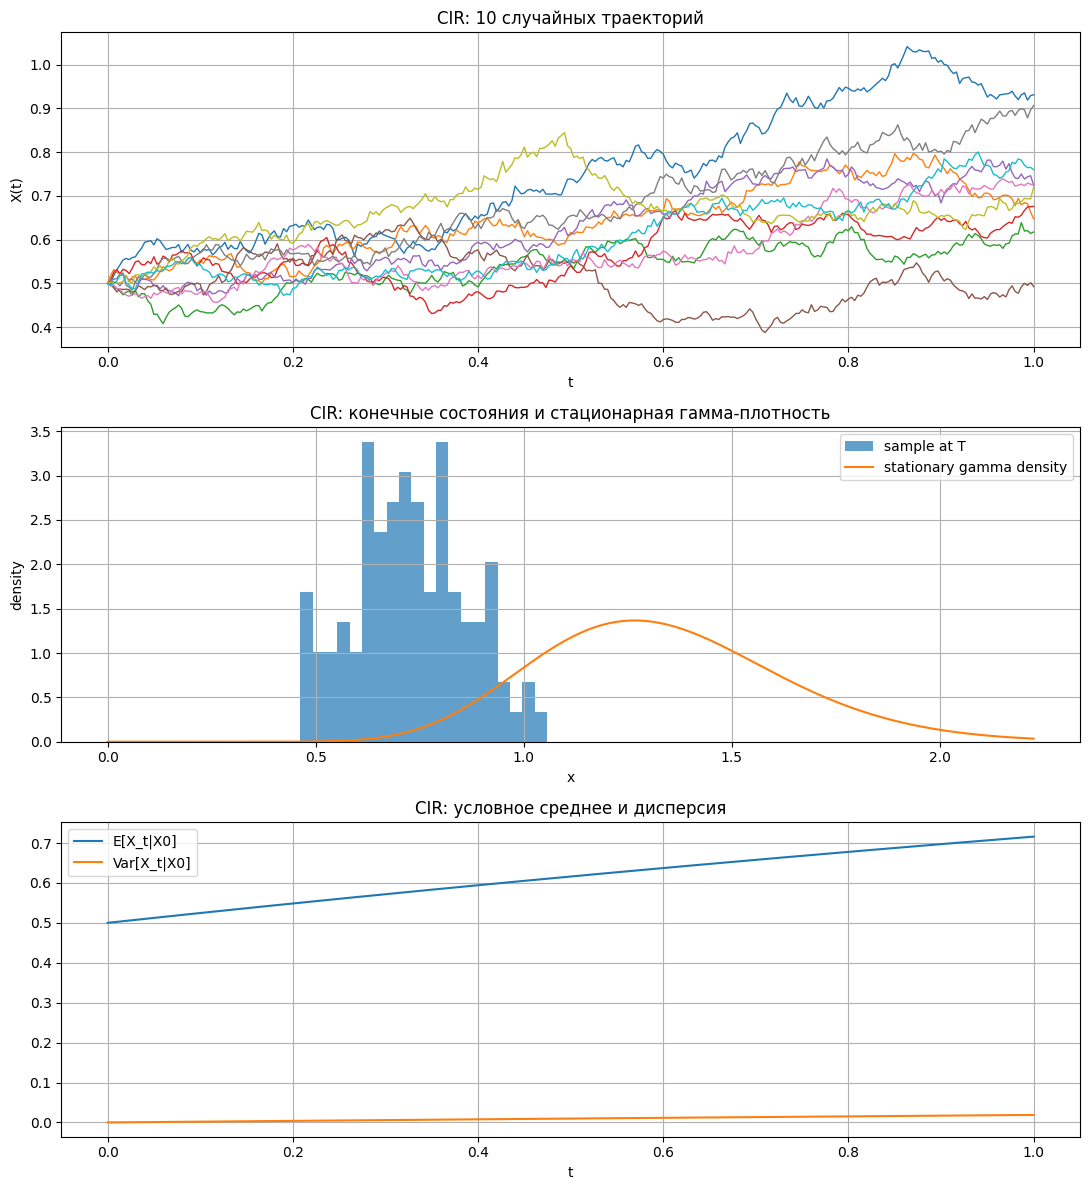

Вывод: OU имеет нормальное стационарное распределение, CIR — гамма-распределение. Так как старт X0=0.5 не стационарный и T=1 невелик, конечная гистограмма лучше совпадает с условным распределением, а к стационарной форме только приближается. Ошибки выборочных моментов уменьшаются при увеличении Nx.


In [28]:

from scipy.stats import norm, gamma
np.random.seed(2027)

T = 1
Nt = 300
Nx = 100
x0 = 0.5
init_state = x0 * np.ones(Nx)

params_OU = [1.0, 1.0, 0.5]      # k, mu, sigma
params_CIR = [0.4, 0.3, 0.2]     # theta1=k*theta, theta2=k, theta3=sigma

OUp = OUprocess(params_OU, T, Nx, Nt, init_state)
CIRp = CIRprocess(params_CIR, T, Nx, Nt, init_state)

t_data, x_ou = OUp.PathGenerator()
t_data, x_cir = CIRp.PathGenerator()

# Теоретические условные моменты
def ou_cond_moments(t, x0, k, mu, sigma):
    m = mu + (x0 - mu) * np.exp(-k*t)
    v = sigma**2 / (2*k) * (1 - np.exp(-2*k*t))
    return m, v

def cir_cond_moments(t, x0, theta1, theta2, sigma):
    k = theta2
    theta = theta1 / theta2
    m = theta + (x0 - theta) * np.exp(-k*t)
    v = (x0 * sigma**2 * np.exp(-k*t) * (1 - np.exp(-k*t)) / k
         + theta * sigma**2 * (1 - np.exp(-k*t))**2 / (2*k))
    return m, v

ou_m, ou_v = ou_cond_moments(t_data, x0, *params_OU)
cir_m, cir_v = cir_cond_moments(t_data, x0, *params_CIR)

# Сравнение выборочных и теоретических моментов в t=0.1, 0.5, 1.0
rows = []
for t in [0.1, 0.5, 1.0]:
    idx = int(round(t * Nt / T))
    for name, x_data, m_theor, v_theor in [
        ('OU', x_ou, ou_m, ou_v),
        ('CIR', x_cir, cir_m, cir_v),
    ]:
        rows.append({
            'process': name,
            't': t,
            'sample_mean': float(np.mean(x_data[idx])),
            'theoretical_mean': float(m_theor[idx]),
            'abs_mean_error': float(abs(np.mean(x_data[idx]) - m_theor[idx])),
            'sample_var': float(np.var(x_data[idx], ddof=1)),
            'theoretical_var': float(v_theor[idx]),
            'abs_var_error': float(abs(np.var(x_data[idx], ddof=1) - v_theor[idx])),
        })
moment_table = pd.DataFrame(rows)
display(moment_table)

# Стационарные плотности
k_ou, mu_ou, sig_ou = params_OU
ou_stat_mean = mu_ou
ou_stat_std = np.sqrt(sig_ou**2 / (2*k_ou))

theta1, theta2, sig_cir = params_CIR
k_cir = theta2
theta_cir = theta1 / theta2
cir_shape = 2 * k_cir * theta_cir / sig_cir**2
cir_scale = sig_cir**2 / (2 * k_cir)

# Условные плотности в T для более честного сравнения конечного состояния
ou_T_mean, ou_T_var = ou_cond_moments(T, x0, *params_OU)
cir_T_mean, cir_T_var = cir_cond_moments(T, x0, *params_CIR)

# Панель для OU
fig, axs = plt.subplots(3, 1, figsize=(11, 12))
for j in range(min(10, Nx)):
    axs[0].plot(t_data, x_ou[:, j], linewidth=1)
axs[0].set_title('OU: 10 случайных траекторий')
axs[0].set_xlabel('t')
axs[0].set_ylabel('X(t)')
axs[0].grid(True)

sample_T = x_ou[-1]
x_grid = np.linspace(min(sample_T.min(), ou_stat_mean - 4*ou_stat_std), max(sample_T.max(), ou_stat_mean + 4*ou_stat_std), 400)
axs[1].hist(sample_T, bins=20, density=True, alpha=0.7, label='sample at T')
axs[1].plot(x_grid, norm.pdf(x_grid, ou_stat_mean, ou_stat_std), label='stationary density')
axs[1].plot(x_grid, norm.pdf(x_grid, ou_T_mean, np.sqrt(ou_T_var)), linestyle='--', label='conditional density at T')
axs[1].set_title('OU: конечные состояния и теоретические плотности')
axs[1].set_xlabel('x')
axs[1].set_ylabel('density')
axs[1].legend()
axs[1].grid(True)

axs[2].plot(t_data, ou_m, label='E[X_t|X0]')
axs[2].plot(t_data, ou_v, label='Var[X_t|X0]')
axs[2].set_title('OU: условное среднее и дисперсия')
axs[2].set_xlabel('t')
axs[2].legend()
axs[2].grid(True)
plt.tight_layout()
plt.show()

# Панель для CIR
fig, axs = plt.subplots(3, 1, figsize=(11, 12))
for j in range(min(10, Nx)):
    axs[0].plot(t_data, x_cir[:, j], linewidth=1)
axs[0].set_title('CIR: 10 случайных траекторий')
axs[0].set_xlabel('t')
axs[0].set_ylabel('X(t)')
axs[0].grid(True)

sample_T = x_cir[-1]
x_grid = np.linspace(1e-8, max(sample_T.max(), gamma.ppf(0.995, a=cir_shape, scale=cir_scale)), 400)
axs[1].hist(sample_T, bins=20, density=True, alpha=0.7, label='sample at T')
axs[1].plot(x_grid, gamma.pdf(x_grid, a=cir_shape, scale=cir_scale), label='stationary gamma density')
axs[1].set_title('CIR: конечные состояния и стационарная гамма-плотность')
axs[1].set_xlabel('x')
axs[1].set_ylabel('density')
axs[1].legend()
axs[1].grid(True)

axs[2].plot(t_data, cir_m, label='E[X_t|X0]')
axs[2].plot(t_data, cir_v, label='Var[X_t|X0]')
axs[2].set_title('CIR: условное среднее и дисперсия')
axs[2].set_xlabel('t')
axs[2].legend()
axs[2].grid(True)
plt.tight_layout()
plt.show()

print('Вывод: OU имеет нормальное стационарное распределение, CIR — гамма-распределение. '
      'Так как старт X0=0.5 не стационарный и T=1 невелик, конечная гистограмма лучше совпадает с условным распределением, '
      'а к стационарной форме только приближается. Ошибки выборочных моментов уменьшаются при увеличении Nx.')
